In [61]:
import tensorflow as tf
import keras
from keras import layers, callbacks
from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np

if len(tf.config.list_physical_devices("GPU")) > 0:
    print("Tensorflow will use GPU acceleration!")

Tensorflow will use GPU acceleration!


In [ ]:
import tensorflow as tf
from tensorflow import keras
from typing import Tuple


def preprocess(image):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = keras.applications.vgg19.preprocess_input(image * 255.0)
    return image


def gram_matrix(tensor):
    batch, h, w, c = tf.unstack(tf.shape(tensor))
    features = tf.reshape(tensor, [batch, h * w, c])
    gram = tf.matmul(features, features, transpose_a=True)
    return gram / tf.cast(h * w * c, tf.float32)


class StyleTransfer(keras.Model):
    def __init__(
        self,
        content_image: tf.Tensor,
        style_image: tf.Tensor,
        content_weight: float = 1e-1,
        style_weight: float = 1e4,
        tvl_weight: float = 1e1,
    ):
        super().__init__()

        self.alpha = tf.constant(content_weight, dtype=tf.float32)
        self.beta = tf.constant(style_weight, dtype=tf.float32)
        self.gamma = tf.constant(tvl_weight, dtype=tf.float32)

        self.style_layers = [
            "block1_conv1",
            "block2_conv1",
            "block3_conv1",
            "block4_conv1",
        ]
        self.content_layers = ["block5_conv2"]

        vgg = keras.applications.VGG19(include_top=False, weights="imagenet")
        vgg.trainable = False
        outputs = [
            vgg.get_layer(name).output
            for name in self.style_layers + self.content_layers
        ]
        self.feature_extractor = keras.Model(vgg.input, outputs)

        initial_image = content_image[tf.newaxis, ...]
        self.generated_image = tf.Variable(
            initial_image, dtype=tf.float32, name="generated_image"
        )
        self.clip = lambda x: tf.clip_by_value(
            x, clip_value_min=0.0, clip_value_max=1.0
        )

        preprocessed_style = preprocess(style_image)[tf.newaxis, ...]
        preprocessed_content = preprocess(content_image)[tf.newaxis, ...]

        target_style_content_features = self.feature_extractor(preprocessed_style)
        target_content_content_features = self.feature_extractor(preprocessed_content)

        num_style_layers = len(self.style_layers)

        self.style_targets = [
            gram_matrix(f) for f in target_style_content_features[:num_style_layers]
        ]

        self.content_targets = target_content_content_features[num_style_layers:]

        self.loss_fn = tf.losses.MeanSquaredError()

    def compile(self, optimizer, loss=None, metrics=None, loss_weights=None, **kwargs):
        super().compile(optimizer=optimizer, metrics=metrics, **kwargs)

    def content_loss(self, generated_features):
        """Calculates L2 loss between generated and target content feature maps."""

        total_content_loss = tf.constant(0.0)
        for generated, target in zip(generated_features, self.content_targets):
            total_content_loss += self.loss_fn(generated, target)

        return total_content_loss

    def style_loss(self, generated_style_features):
        total_style_loss = tf.constant(0.0)
        for generated_feature, style_target in zip(
            generated_style_features, self.style_targets
        ):
            generated_gram = gram_matrix(generated_feature)
            total_style_loss += self.loss_fn(style_target, generated_gram)

        return total_style_loss

    def total_variation_loss(self, img):
        horizontal_diff = tf.abs(img[:, 1:, :-1, :] - img[:, :-1, :-1, :])
        vertical_diff = tf.abs(img[:, :-1, 1:, :] - img[:, :-1, :-1, :])

        return tf.reduce_sum(horizontal_diff + vertical_diff)

    @tf.function
    def compute_loss(self) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        processed_generated = preprocess(self.generated_image)

        all_features = self.feature_extractor(processed_generated)

        num_style_layers = len(self.style_layers)
        generated_style_features = all_features[:num_style_layers]
        generated_content_features = all_features[num_style_layers:]

        C_loss = self.content_loss(generated_content_features)
        S_loss = self.style_loss(generated_style_features)
        TV_loss = self.total_variation_loss(self.generated_image)

        total_loss = (
            (self.alpha * C_loss) + (self.beta * S_loss) + (self.gamma * TV_loss)
        )

        return (
            total_loss,
            (self.alpha * C_loss),
            (self.beta * S_loss),
            (self.gamma * TV_loss),
        )

    @tf.function
    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, c_loss, s_loss, _ = self.compute_loss()

        trainable_vars = [self.generated_image]
        gradients = tape.gradient(total_loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.generated_image.assign(self.clip(self.generated_image))

        return total_loss, c_loss, s_loss

    @tf.function
    def call(self, inputs=None):
        return self.generated_image

In [262]:
IMG_SIZE = 256


def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img


style_image_path = "data/van_gogh_style.jpg"

content_image_path = "data/example.jpg"
style_image = load_and_preprocess(style_image_path)
content_image = load_and_preprocess(content_image_path)

model = StyleTransfer(
    style_image=style_image,
    content_image=content_image,
    content_weight=10,
    style_weight=1e3,
    tvl_weight=10,
)

In [265]:
model.compile(optimizer=keras.optimizers.legacy.Adam(learning_rate=1e-2))

epochs = 1000
loss_history = []

for step in range(epochs):
    total_loss, content_loss, style_loss = model.train_step(None)
    current_loss = total_loss.numpy()
    loss_history.append((total_loss, content_loss, style_loss))

    if step % 100 == 0 or step == epochs - 1:
        print(f"Step {step}: Loss {total_loss:.4f}")

Step 0: Loss 318228454703104.0000
Step 100: Loss 3938687385600.0000
Step 200: Loss 1993807495168.0000
Step 300: Loss 1351666761728.0000
Step 400: Loss 1034485497856.0000
Step 500: Loss 849941233664.0000
Step 600: Loss 727061430272.0000
Step 700: Loss 639738314752.0000
Step 800: Loss 573162061824.0000
Step 900: Loss 521140600832.0000
Step 999: Loss 479789973504.0000


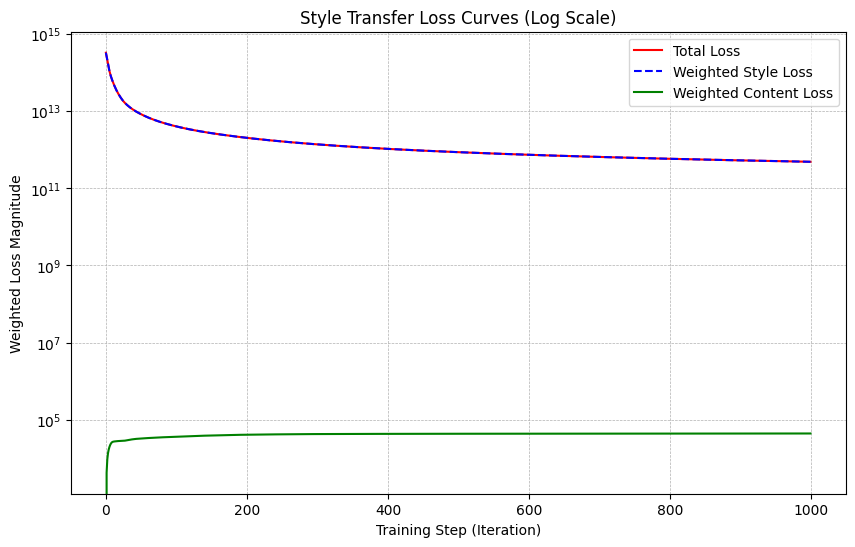

In [266]:
history_np = np.array(loss_history)
total_loss = history_np[:, 0]
content_loss = history_np[:, 1]
style_loss = history_np[:, 2]
steps = np.arange(len(total_loss))

plt.figure(figsize=(10, 6))

plt.plot(steps, total_loss, label="Total Loss", color="red")
plt.plot(steps, style_loss, label="Weighted Style Loss", color="blue", linestyle="--")
plt.plot(steps, content_loss, label="Weighted Content Loss", color="green")

plt.title("Style Transfer Loss Curves (Log Scale)")
plt.xlabel("Training Step (Iteration)")
plt.ylabel("Weighted Loss Magnitude")
plt.yscale("log")  # Log scale is crucial for visualization!
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.show()

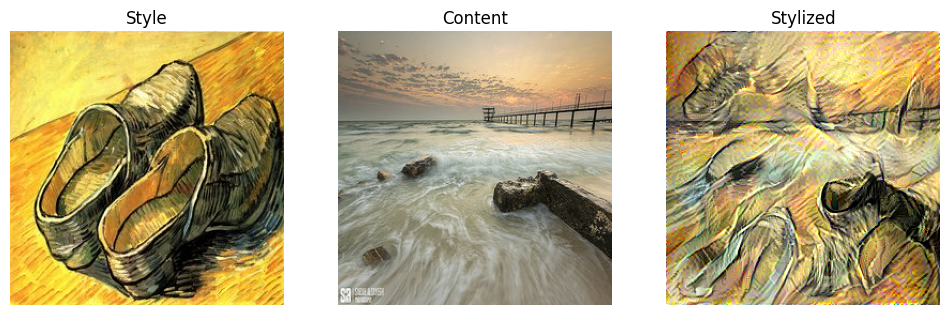

In [267]:
styled_image = model.call()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(style_image)
plt.title("Style")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(content_image)
plt.title("Content")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(tf.reshape(styled_image, (IMG_SIZE, IMG_SIZE, 3)).numpy())
plt.title("Stylized")
plt.axis("off")

plt.show()



--- Starting Config A: alpha=10000.0, beta=1.0, gamma=10 ---
  Step 0: Total Loss 1452026.75
  Step 200: Total Loss 766974.12
  Step 400: Total Loss 639062.69
  Step 600: Total Loss 599771.88
  Step 800: Total Loss 554624.62
  Step 1000: Total Loss 534807.81
  Step 1200: Total Loss 523605.88
  Step 1400: Total Loss 527032.88
  Step 1600: Total Loss 507310.00
  Step 1800: Total Loss 497023.97
  Step 1999: Total Loss 498317.56

--- Starting Config B: alpha=1.0, beta=10000.0, gamma=10 ---
  Step 0: Total Loss 13113456640.00
  Step 200: Total Loss 109352224.00
  Step 400: Total Loss 51513164.00
  Step 600: Total Loss 33838332.00
  Step 800: Total Loss 25482460.00
  Step 1000: Total Loss 20701580.00
  Step 1200: Total Loss 17656116.00
  Step 1400: Total Loss 15658280.00
  Step 1600: Total Loss 14425742.00
  Step 1800: Total Loss 13078380.00
  Step 1999: Total Loss 15755133.00

--- Starting Config C: alpha=10.0, beta=10.0, gamma=10 ---
  Step 0: Total Loss 13254011.00
  Step 200: Total Loss

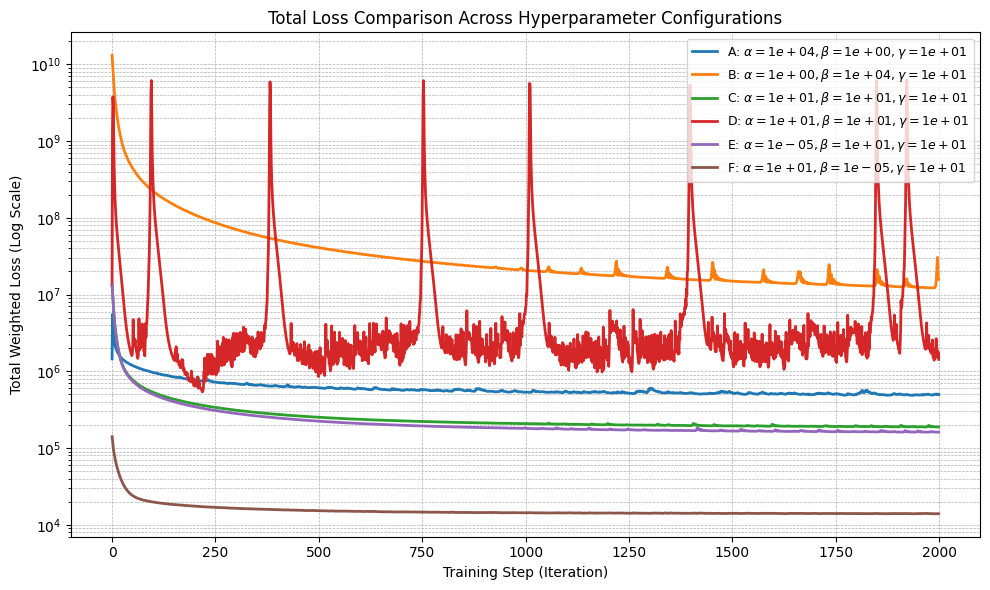

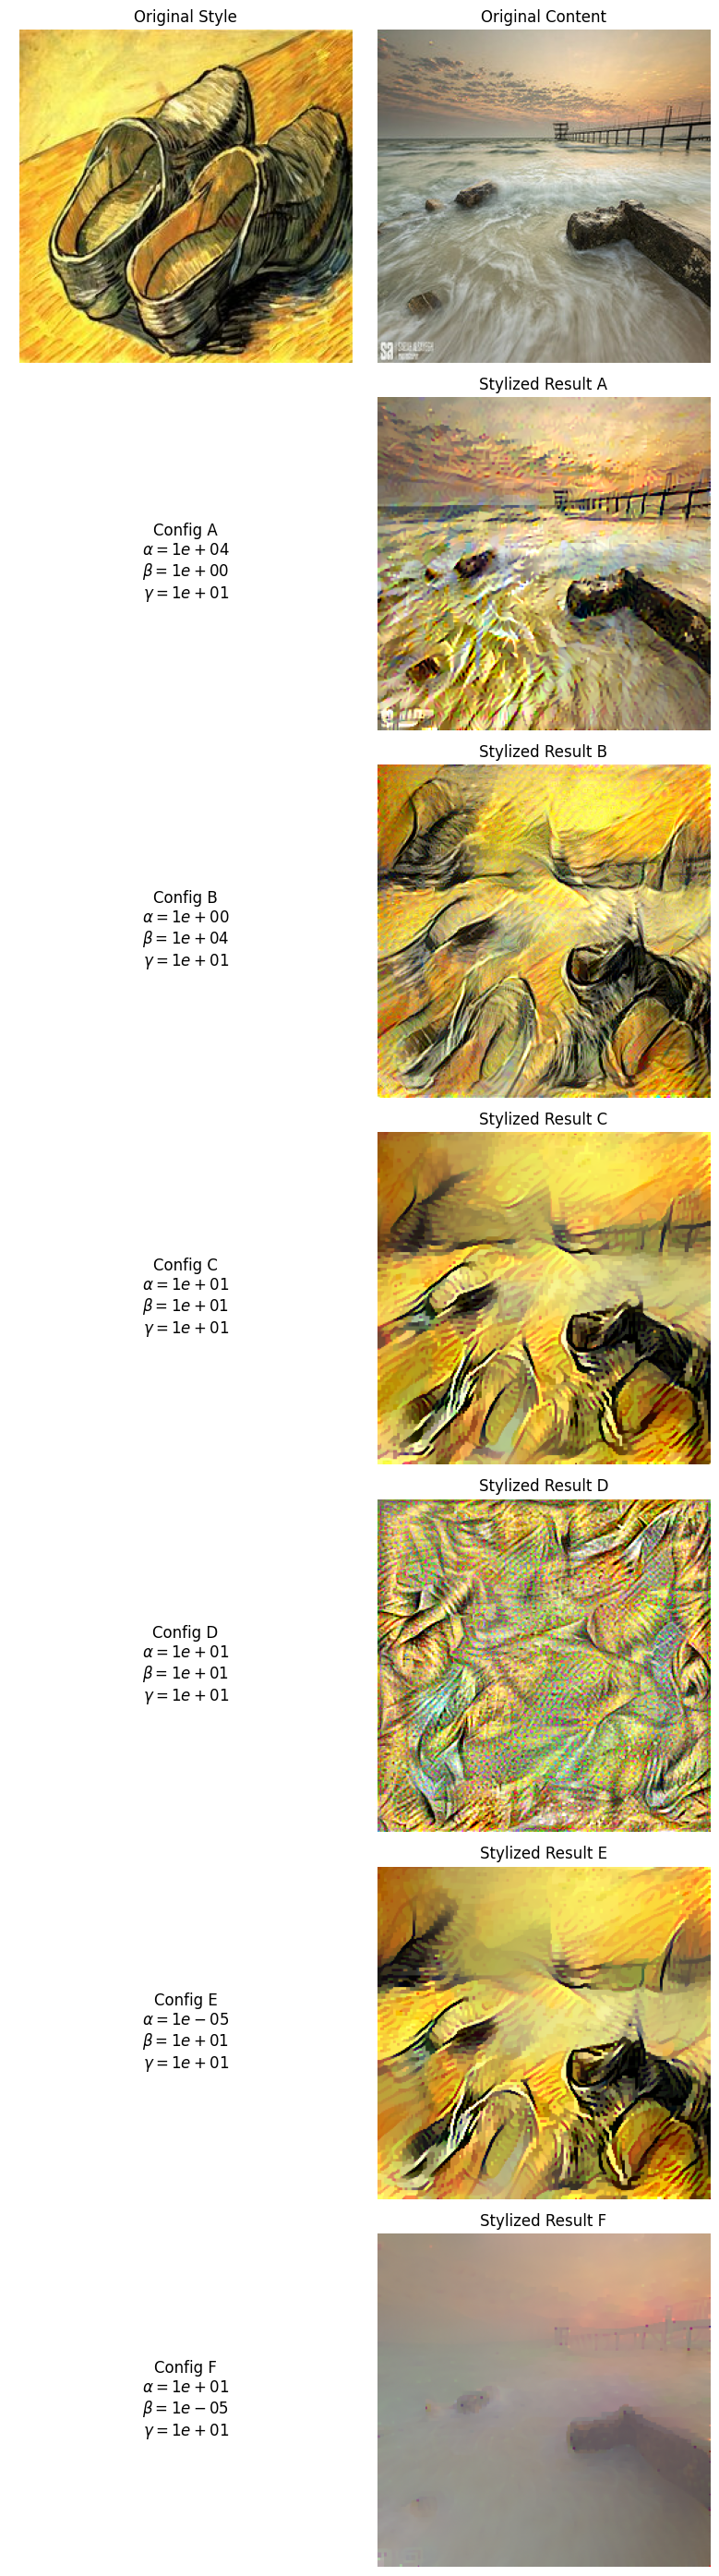

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt


def run_experiment(
    config_name, content_weight, style_weight, tvl_weight=10, epochs=2000, lr=1e-2
):
    model = StyleTransfer(
        style_image=style_image,
        content_image=content_image,
        content_weight=content_weight,
        style_weight=style_weight,
        tvl_weight=tvl_weight,
    )

    model.compile(optimizer=keras.optimizers.legacy.Adam(learning_rate=lr))

    loss_history = []

    print(
        f"\n--- Starting Config {config_name}: alpha={content_weight}, beta={style_weight}, gamma={tvl_weight} ---"
    )
    for step in range(epochs):
        total_loss, content_loss, style_loss = model.train_step(None)

        loss_history.append(
            (total_loss.numpy(), content_loss.numpy(), style_loss.numpy())
        )

        if step % 200 == 0 or step == epochs - 1:
            print(f"  Step {step}: Total Loss {total_loss.numpy():.2f}")

    styled_image_tensor = model.call()

    history_np = np.array(loss_history)

    return {
        "name": config_name,
        "alpha": content_weight,
        "beta": style_weight,
        "gamma": tvl_weight,
        "loss_data": history_np,
        "styled_image": tf.squeeze(styled_image_tensor, axis=0).numpy(),
    }


EXPERIMENTS = [
    run_experiment("A", content_weight=1e4, style_weight=1e0),
    run_experiment("B", content_weight=1e0, style_weight=1e4),
    run_experiment("C", content_weight=1e1, style_weight=1e1),
    run_experiment("D", content_weight=1e1, style_weight=1e1, lr=10),
    run_experiment("E", content_weight=1e-5, style_weight=1e1),
    run_experiment("F", content_weight=1e1, style_weight=1e-5),
    run_experiment("G", content_weight=1e0, style_weight=1e2),
]


def plot_loss_mosaic(experiments):
    """Plots the Total Loss for all experiments in a single figure."""
    plt.figure(figsize=(10, 6))

    for exp in experiments:
        total_loss = exp["loss_data"][:, 0]
        steps = np.arange(len(total_loss))

        label = (
            f"{exp['name']}: "
            f"$\\alpha={exp['alpha']:.0e}, \\beta={exp['beta']:.0e}, \\gamma={exp['gamma']:.0e}$"
        )

        plt.plot(steps, total_loss, label=label, linewidth=2)

    plt.title("Total Loss Comparison Across Hyperparameter Configurations")
    plt.xlabel("Training Step (Iteration)")
    plt.ylabel("Total Weighted Loss (Log Scale)")
    plt.yscale("log")
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend(loc="upper right", fontsize=9)
    plt.tight_layout()


plot_loss_mosaic(EXPERIMENTS)


def plot_image_mosaic(experiments):
    num_experiments = len(experiments)

    num_rows = 1 + num_experiments

    fig, axes = plt.subplots(num_rows, 2, figsize=(8, 4 * num_rows))

    axes[0, 0].imshow(style_image.numpy())
    axes[0, 0].set_title("Original Style", fontsize=12)
    axes[0, 0].axis("off")

    axes[0, 1].imshow(content_image.numpy())
    axes[0, 1].set_title("Original Content", fontsize=12)
    axes[0, 1].axis("off")

    for i, exp in enumerate(experiments):
        row_index = i + 1

        title = (
            f"Config {exp['name']}\n"
            f"$\\alpha={exp['alpha']:.0e}$\n"
            f"$\\beta={exp['beta']:.0e}$\n"
            f"$\\gamma={exp['gamma']:.0e}$"
        )

        axes[row_index, 0].text(
            0.5,
            0.5,
            title,
            ha="center",
            va="center",
            fontsize=12,
            transform=axes[row_index, 0].transAxes,
        )

        axes[row_index, 1].imshow(exp["styled_image"])
        axes[row_index, 1].set_title(f"Stylized Result {exp['name']}", fontsize=12)
        axes[row_index, 1].axis("off")

    plt.tight_layout()
    plt.show()


plot_image_mosaic(EXPERIMENTS)